# PTK (PARSEC Tool Kit) - Tutorial

The folder `data/ROT_0.00_Z0.02_Y0.284` contains simulations of stars with:
- no rotation (`ROT_0.00`)
- metallicity Z = 0.02 (`Z0.02`)
- helium mass fraction Y = 0.284 (`Y0.284`)

The files inside are:
- **F7/F71**: global properties at each timestep
    - `*.UNF` are Fortran binary files, they are the complete datasets.
    - `*.PMS` are summary tables, with fewer columns and fast to read.
- **F8**: radial profiles of physical quantities at each timestep

---
## 1. Key concepts
A **Track** is a single stellar evolutionary sequence computed at a fixed initial mass.

A **Track set** is a collection of tracks sharing the same initial parameters (metallicity $Z$, rotation $\omega$, etc.) but different initial masses $M_{ini}$.

Key **evolutionary phases**:

| Phase | Meaning |
| --- | --- |
| `ZAMS` | Zero-Age Main Sequence |
| `TAMS` | Terminal-Age Main Sequence |
| `CHeB_beg` / `CHeB_end` | Start / end of core helium burning |
| `CCB_beg` / `CCB_end` | Start / end of core carbon burning |

---
## 2. Loading track sets (F7)
### Single set
`Load_Set` reads all tracks in a directory and returns a `TrackSet` object.

In [1]:
!tree "../data/ROT_0.00_Z0.02_Y0.284"

../data/ROT_0.00_Z0.02_Y0.284
├── Z0.02Y0.284O_IN0.0OUTA1.74_F7_M100.0.PMS
├── Z0.02Y0.284O_IN0.0OUTA1.74_F7_M100.0.UNF
├── Z0.02Y0.284O_IN0.0OUTA1.74_F7_M10.0.PMS
├── Z0.02Y0.284O_IN0.0OUTA1.74_F7_M10.0.UNF
├── Z0.02Y0.284O_IN0.0OUTA1.74_F7_M110.0.PMS
├── Z0.02Y0.284O_IN0.0OUTA1.74_F7_M110.0.UNF
├── Z0.02Y0.284O_IN0.0OUTA1.74_F7_M11.0.PMS
├── Z0.02Y0.284O_IN0.0OUTA1.74_F7_M11.0.UNF
├── Z0.02Y0.284O_IN0.0OUTA1.74_F7_M120.0.PMS
├── Z0.02Y0.284O_IN0.0OUTA1.74_F7_M120.0.UNF
├── Z0.02Y0.284O_IN0.0OUTA1.74_F7_M12.0.PMS
├── Z0.02Y0.284O_IN0.0OUTA1.74_F7_M12.0.UNF
├── Z0.02Y0.284O_IN0.0OUTA1.74_F7_M130.0.PMS
├── Z0.02Y0.284O_IN0.0OUTA1.74_F7_M130.0.UNF
├── Z0.02Y0.284O_IN0.0OUTA1.74_F7_M140.0.PMS
├── Z0.02Y0.284O_IN0.0OUTA1.74_F7_M140.0.UNF
├── Z0.02Y0.284O_IN0.0OUTA1.74_F7_M14.0.PMS
├── Z0.02Y0.284O_IN0.0OUTA1.74_F7_M14.0.UNF
├── Z0.02Y0.284O_IN0.0OUTA1.74_F7_M150.0.PMS
├── Z0.02Y0.284O_IN0.0OUTA1.74_F7_M150.0.UNF
├── Z0.02Y0.284O_IN0.0OUTA1.74_F7_M160.0.PMS
├── Z0.02Y0.284O_IN0.0OUTA1.74_F7

In [2]:
from ptk import Load_Set

# load F7 + F71 files, save parsed data as pickle for faster re-loading
setZ02 = Load_Set("../data/ROT_0.00_Z0.02_Y0.284", fread=True, fsave=True)

# keep only F71 when both F7 and F71 are available
setZ02.ReduceSet()

print(setZ02)


----------------------------------------
Reading set ROT_0.00_Z0.02_Y0.284: 


Reading track -> Z0.02Y0.284O_IN0.0OUTA1.74_F7_M95.0.UNF: 100%|█| 88/88 [00:10<0


Done!

Set ROT_0.00_Z0.02_Y0.284: Saving Tracks ...
Set ROT_0.00_Z0.02_Y0.284 saved successfully.

Set: ROT_0.00_Z0.02_Y0.284 with 88 tracks.


In [3]:
# inspect the set to see all the tracks inside
setZ02.info

Set directory: ../data/ROT_0.00_Z0.02_Y0.284                

Set name:
ROT_0.00_Z0.02_Y0.284               

Number of tracks: 88

   ID | Track name
______|______________________________________________________
    0 | Z0.02Y0.284O_IN0.0OUTA1.74_F7_M2.00.UNF
    1 | Z0.02Y0.284O_IN0.0OUTA1.74_F7_M2.20.UNF
    2 | Z0.02Y0.284O_IN0.0OUTA1.74_F7_M2.40.UNF
    3 | Z0.02Y0.284O_IN0.0OUTA1.74_F7_M2.60.UNF
    4 | Z0.02Y0.284O_IN0.0OUTA1.74_F7_M2.80.UNF
    5 | Z0.02Y0.284O_IN0.0OUTA1.74_F7_M3.00.UNF
    6 | Z0.02Y0.284O_IN0.0OUTA1.74_F7_M3.20.UNF
    7 | Z0.02Y0.284O_IN0.0OUTA1.74_F7_M3.40.UNF
    8 | Z0.02Y0.284O_IN0.0OUTA1.74_F7_M3.60.UNF
    9 | Z0.02Y0.284O_IN0.0OUTA1.74_F7_M3.80.UNF
   10 | Z0.02Y0.284O_IN0.0OUTA1.74_F7_M4.00.UNF
   11 | Z0.02Y0.284O_IN0.0OUTA1.74_F7_M4.20.UNF
   12 | Z0.02Y0.284O_IN0.0OUTA1.74_F7_M4.40.UNF
   13 | Z0.02Y0.284O_IN0.0OUTA1.74_F7_M4.60.UNF
   14 | Z0.02Y0.284O_IN0.0OUTA1.74_F7_M4.80.UNF
   15 | Z0.02Y0.284O_IN0.0OUTA1.74_F7_M5.00.UNF
   16 | Z0.02Y0.284

### Multiple sets at once
`Find_and_load_Sets` finds recursively all sub-directories in a path to load each one as a `TrackSet` and returns a list.

In [4]:
!tree "../PTK/test/data/SET_SAMPLES"

../PTK/test/data/SET_SAMPLES
├── BIG_UNF
│   ├── Z0.008Y0.263OUTA1.74_F7_M.60.PMS.HB
│   ├── Z0.014Y0.273TCOS0.1IVAR1_F7_M2.50.UNF
│   ├── Z0.014Y0.273TCOS1IVAR1_F7_M2.50.UNF
│   └── Z0.014Y0.273TCOS3IVAR1_F7_M2.50.UNF
├── BIG_UNF.pickle
├── MESA_TRACK
│   └── history_M10.data
├── MESA_TRACK.pickle
├── MOSSE
│   ├── M41.9Z0.0002.dat
│   ├── M57.6Z0.0002.dat
│   ├── M88Z0.0002.dat
│   └── M99.3Z0.0002.dat
├── MOSSE.pickle
├── Z0.008
│   ├── Z0.008Y0.263O_IN0.00OUTA1.74_F7_M100.0.PMS
│   ├── Z0.008Y0.263O_IN0.00OUTA1.74_F7_M100.0.UNF
│   ├── Z0.008Y0.263O_IN0.00OUTA1.74_F7_M10.0.PMS
│   ├── Z0.008Y0.263O_IN0.00OUTA1.74_F7_M10.0.UNF
│   ├── Z0.008Y0.263O_IN0.00OUTA1.74_F7_M200.0.PMS
│   ├── Z0.008Y0.263O_IN0.00OUTA1.74_F7_M200.0.UNF
│   ├── Z0.008Y0.263O_IN0.00OUTA1.74_F7_M2.00.PMS
│   ├── Z0.008Y0.263O_IN0.00OUTA1.74_F7_M20.0.PMS
│   ├── Z0.008Y0.263O_IN0.00OUTA1.74_F7_M2.00.UNF
│   ├── Z0.008Y0.263O_IN0.00OUTA1.74_F7_M20.0.UNF
│   ├── Z0.008Y0.263O_IN0.00OUTA1.74_F7_M5.00.PMS
│   ├── Z0

In [5]:
from ptk import Find_and_load_Sets

# example: load the test sets bundled with PTK
all_sets = Find_and_load_Sets("../PTK/test/data/SET_SAMPLES/")
print(all_sets)

../PTK/test/data/SET_SAMPLES/ contains 5 sets
Set BIG_UNF: 
Reading Tracks from pickle files ...
Done!

Set BIG_UNF already exists.                   
(If you want to overwrite use the fsave=True.)

Set MESA_TRACK: 
Reading Tracks from pickle files ...
Done!

Set MESA_TRACK already exists.                   
(If you want to overwrite use the fsave=True.)

Set MOSSE: 
Reading Tracks from pickle files ...
Done!

Set MOSSE already exists.                   
(If you want to overwrite use the fsave=True.)

Set Z0.008: 
Reading Tracks from pickle files ...
Done!

Set Z0.008 already exists.                   
(If you want to overwrite use the fsave=True.)

Set Z0.017: 
Reading Tracks from pickle files ...
Done!

Set Z0.017 already exists.                   
(If you want to overwrite use the fsave=True.)

[TrackSet(set_path='/home/alberto/Documents/Università/thesis/PTK/test/data/SET_SAMPLES/BIG_UNF', name='BIG_UNF', empty=False), TrackSet(set_path='/home/alberto/Documents/Università/thesis/PT

---
## 3. Inspecting individual tracks
`TrackSet.tracks` gives a list of `parsec_track` objects, one for each track.

In [6]:
# select a single track
track = setZ02.tracks[0]
track.info

      file_path = /home/alberto/Documents/Università/thesis/data/ROT_0.00_Z0.02_Y0.284/Z0.02Y0.284O_IN0.0OUTA1.74_F7_M2.00.UNF
     RFullTrack = False
             ID = 0
    _auto_solve = True
   _binary_file = True
_standard_track = True
           code = parsec
         PureHe = False
             HB = False
            TAB = False
Restart_from_jo = False
            UNF = True
    old_version = False
     _file_path = /home/alberto/Documents/Università/thesis/data/ROT_0.00_Z0.02_Y0.284/Z0.02Y0.284O_IN0.0OUTA1.74_F7_M2.00.UNF
           name = Z0.02Y0.284O_IN0.0OUTA1.74_F7_M2.00.UNF
    TAB_release = False
        omega_i = 0.0
        F7_type = F7
           mass = 2.0
              Z = 0.02
              Y = 0.284
              X = 0.696
       is_empty = False
          _data = ...
            seq = ...
         preseq = ...
           keys = ('MODE', 'MASS', 'AGE', 'Dtime', 'LOG_L', 'LOG_TE', 'RSTAR', 'CONV', 'QSCHW', 'QDISC', 'QH_HE', 'QHEL', 'Q_HE_CO', 'QCAROX', 'LOG_Tc', 'LOG

In [7]:
import pandas as pd

# evolutionary sequence as a DataFrame
df = pd.DataFrame(track.preseq)
df

,MODE,MASS,AGE,Dtime,LOG_L,LOG_TE,RSTAR,CONV,QSCHW,QDISC,...,R20L10,MU20,T2_3L10,RH2_3L10,P2_3L10,TE2_3L10,R2_3L10,MU2_3,FIT_M,COMP_TIME
0,188.0,2.000000,1.624412e+03,1.624312e+03,1.974628,3.644229,1.161310e+12,0.980000,0.000000,0.000000,...,12.064393,1.309293,3.644257,-7.504921,3.941217,3.644229,12.064949,1.311899,0.980,163.886
1,189.0,2.000000,3.212513e+03,1.588101e+03,1.957958,3.645338,1.133436e+12,0.980000,0.000000,0.000000,...,12.053854,1.308501,3.646364,-7.495458,3.952804,3.645335,12.054402,1.311335,0.980,164.577
2,190.0,2.000000,4.482918e+03,1.270406e+03,1.939156,3.646567,1.102901e+12,0.980000,0.000000,0.000000,...,12.042006,1.307600,3.648087,-7.485783,3.964231,3.646568,12.042535,1.311072,0.980,165.259
3,191.0,2.000000,5.455952e+03,9.730335e+02,1.923765,3.647564,1.078568e+12,0.980000,0.000000,0.000000,...,12.032327,1.306930,3.648178,-7.480546,3.969532,3.647562,12.032851,1.311475,0.980,165.948
4,192.0,2.000000,6.258565e+03,8.026133e+02,1.911114,3.648380,1.058986e+12,0.980000,0.000000,0.000000,...,12.024378,1.306369,3.649123,-7.474379,3.976661,3.648380,12.024890,1.310919,0.980,166.753
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306,494.0,1.999983,1.960977e+07,1.134984e+06,1.200380,3.959347,1.115809e+11,0.198045,0.125470,0.273659,...,11.047216,0.695767,3.961119,-8.125743,3.689927,3.959346,11.047591,0.867685,0.999,519.714
307,495.0,1.999982,2.088663e+07,1.276857e+06,1.200421,3.959346,1.115863e+11,0.198045,0.126527,0.281687,...,11.047237,0.695757,3.961141,-8.125780,3.689934,3.959346,11.047612,0.865911,0.999,520.938
308,496.0,1.999980,2.232310e+07,1.436464e+06,1.200538,3.959356,1.115963e+11,0.198045,0.126527,0.289627,...,11.047276,0.695312,3.961310,-8.126021,3.690039,3.959355,11.047651,0.853331,0.999,522.187
309,497.0,1.999979,2.393912e+07,1.616023e+06,1.200563,3.959310,1.116231e+11,0.198045,0.127583,0.297478,...,11.047381,0.697043,3.960894,-8.125495,3.689716,3.959310,11.047755,0.883586,0.999,523.514


### Track selection helpers
| Method | Description |
| --- | --- |
| `TrackSet.SelEq("mass", value_or_list)` | Select tracks with mass equal to value(s) |
| `TrackSet.SelGe("mass", value)` | Select tracks with mass ≥ value |
| `TrackSet.SelByName(name)` | Select by track filename |

In [8]:
# subsample: 1 track every N masses
N = 20
set_sub = setZ02.SelEq("mass", setZ02.masses[::N])
set_sub.info

Set directory: ./Selected_SET                

Set name:
Selected_SET               

Number of tracks: 5

   ID | Track name
______|______________________________________________________
    0 | Z0.02Y0.284O_IN0.0OUTA1.74_F7_M2.00.UNF
   20 | Z0.02Y0.284O_IN0.0OUTA1.74_F7_M6.00.UNF
   40 | Z0.02Y0.284O_IN0.0OUTA1.74_F7_M10.0.UNF
   60 | Z0.02Y0.284O_IN0.0OUTA1.74_F7_M95.0.UNF
   80 | Z0.02Y0.284O_IN0.0OUTA1.74_F7_M290.0.UNF


---
## 4. Loading radial profiles (F8)
`read_F8` reads a single F8 file and returns:
- `F8_str`: list of radial profiles (one per timestep)
- `F8_str_info`: summary table (one row per timestep)
- `F8_track_info`: global track metadata

**Note**: the number of F8 timestps may differ from the F7 track length.

### Summary table
`F8_str_info` is an array with a row for each timestep. It contains global info about each stellar model:

| Column | Meaning |
| --- | --- |
| `ModNumb` | Model number (sequential ID) |
| `GMS_0` | Current mass of the star (in solar masses) |
| `Age` | Age of the star at current timestep (in years) |
| `...` | ... |

In [9]:
from pathlib import Path
from ptk import read_F8

tracks_dir = Path("../data/ROT_0.00_Z0.02_Y0.284")

# load the F8 file for the 10 M☉ track
for F8_file in tracks_dir.rglob("*F81_M10.0"):
    F8_str, F8_str_info, F8_track_info = read_F8(F8_file)
    
print(f"F8 timesteps: {len(F8_str)}")

../data/ROT_0.00_Z0.02_Y0.284/Z0.02Y0.284O_IN0.0OUTA1.74_F81_M10.0
finish 2472
F8 timesteps: 2472


In [10]:
import pandas as pd

# radial profile at timestep 0
# rows = radial shells, cols = physical quantities
profile0 = pd.DataFrame(F8_str[0])
profile0.head()

,M,R,T,P,RHO,PSI,KAP,H_P,V_MLT,PT,...,XHE,XC,XN,XO,XNE,XNA,XMG,XAL,XSI,XS32
0,1.000000,5.244895e+12,3589.037046,0.689109,2.557523e-14,-32.926865,0.000104,5.583166e+11,0.000000,0.000000,...,0.284,0.00364,0.000973,0.008823,0.002024,0.000047,0.000886,0.000076,0.000955,0.000444
1,1.000000,5.180384e+12,4424.481454,35.490272,1.322024e-08,-20.310438,0.020885,5.426662e+07,0.000000,0.000000,...,0.284,0.00364,0.000973,0.008823,0.002024,0.000047,0.000886,0.000076,0.000955,0.000444
2,1.000000,5.180345e+12,4473.538919,36.062683,1.356545e-08,-20.285864,0.021844,5.373782e+07,0.000000,0.000000,...,0.284,0.00364,0.000973,0.008823,0.002024,0.000047,0.000886,0.000076,0.000955,0.000444
3,1.000000,5.179018e+12,4812.265426,39.696325,1.572726e-08,-20.155884,0.027006,5.099543e+07,0.000000,0.000000,...,0.284,0.00364,0.000973,0.008823,0.002024,0.000047,0.000886,0.000076,0.000955,0.000444
4,0.999994,5.161257e+12,11026.726298,77.111978,2.424261e-08,-14.309409,103.908835,6.382562e+07,231475.399615,298.756174,...,0.284,0.00364,0.000973,0.008823,0.002024,0.000047,0.000886,0.000076,0.000955,0.000444


In [11]:
# summary table across all timesteps
summary = pd.DataFrame(F8_str_info)
print(f"Age range: {summary['Age'].iloc[0]:.1f} - {summary['Age'].iloc[-1]:.1f} yr")
summary.head()

Age range: 0.1 - 23657295.3 yr


,ModNumb,my_k,AK_ENV_MD,AK_ROS_MD,A_IH_BNV_MD,A_IHE_BNV_MD,A_IC_BNV_MD,GMS_0,Age
0,230.0,38.0,36.0,0.0,38.0,0.0,0.0,10.0,0.100000
1,231.0,38.0,36.0,0.0,38.0,0.0,0.0,10.0,124.480214
2,232.0,38.0,36.0,0.0,38.0,0.0,0.0,10.0,264.407955
3,233.0,38.0,36.0,0.0,38.0,0.0,0.0,10.0,421.826663
4,234.0,38.0,36.0,0.0,38.0,0.0,0.0,10.0,598.922710


## 5. Plotting
### HR diagram

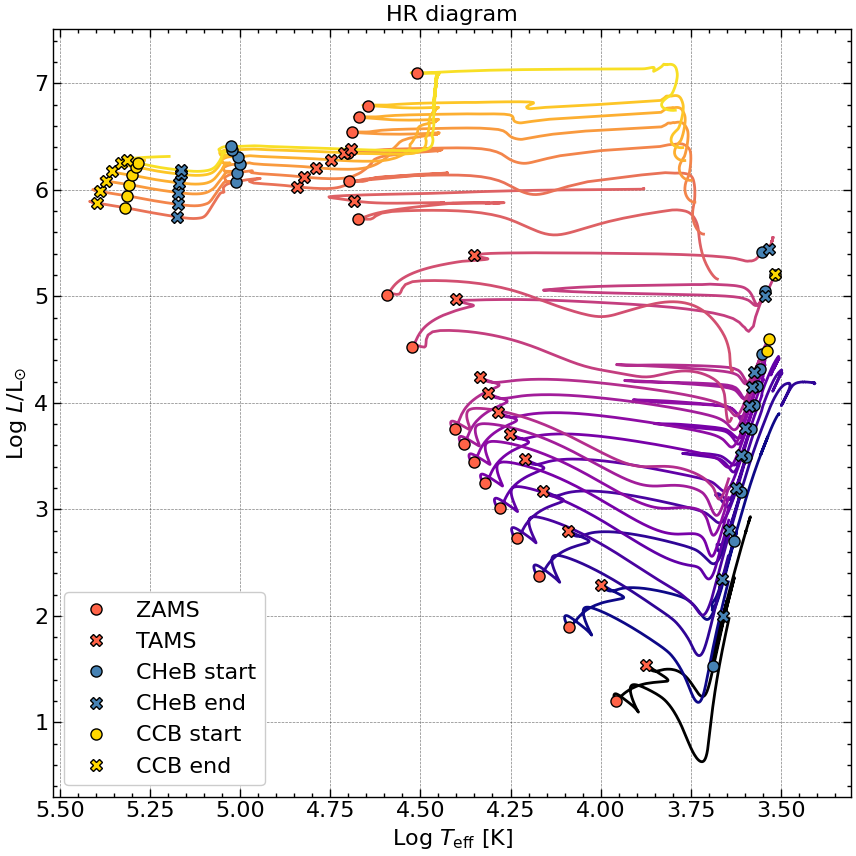

In [12]:
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(["science", "notebook", "grid"])

# reduce the set by selecting 1 track every N
N = 5
set_sub = setZ02.SelEq("mass", setZ02.masses[::N])

# select tables at different phases
ZAMS = set_sub.phase_selector("ZAMS")
TAMS = set_sub.phase_selector("TAMS")
CHeB_beg = set_sub.phase_selector("CHeB_beg")
CHeB_end = set_sub.phase_selector("CHeB_end")
CCB_beg = set_sub.phase_selector("CCB_beg")
CCB_end = set_sub.phase_selector("CCB_end")

# plot settings
ms = 8 # marker size
mec = "k" # marker edge color
cols = ["tomato", "steelblue", "gold"]

fig,ax = plt.subplots(figsize=(9,9))
set_sub.HR_plot(
    ax,
    cmap="plasma",
    legend=False,
    plotseq="all" # "ms": > main sequence, "pms": pre main sequence, "all": entire track
)

ax.plot(ZAMS["LOG_TE"], ZAMS["LOG_L"], "o", c=cols[0], mec=mec, ms=ms, label="ZAMS")
ax.plot(TAMS["LOG_TE"], TAMS["LOG_L"], "X", c=cols[0], mec=mec, ms=ms, label="TAMS")
ax.plot(CHeB_beg["LOG_TE"], CHeB_beg["LOG_L"], "o", c=cols[1], mec=mec, ms=ms, label="CHeB start")
ax.plot(CHeB_end["LOG_TE"], CHeB_end["LOG_L"], "X", c=cols[1], mec=mec, ms=ms, label="CHeB end")
ax.plot(CCB_beg["LOG_TE"], CCB_beg["LOG_L"], "o", c=cols[2], mec=mec, ms=ms, label="CCB start")
ax.plot(CCB_end["LOG_TE"], CCB_end["LOG_L"], "X", c=cols[2], mec=mec, ms=ms, label="CCB end")

ax.legend()
ax.set_title("HR diagram")
fig.tight_layout()
plt.show()

Selecting one track instead:

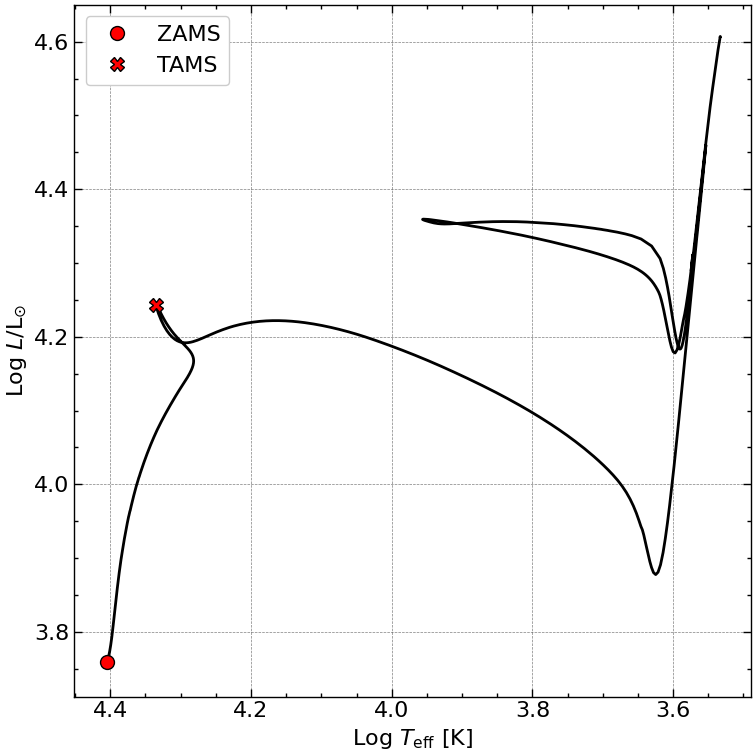

In [13]:
M10 = set_sub.SelEq("mass", 10)
ZAMS = M10.zams
TAMS = M10.tams

fig,ax = plt.subplots(figsize=(8,8))
M10.HR_plot(
    ax, legend=False
)
ax.plot(ZAMS["LOG_TE"], ZAMS["LOG_L"], "or", ms=10, mec="k", label="ZAMS")
ax.plot(TAMS["LOG_TE"], TAMS["LOG_L"], "Xr", ms=10, mec="k", label="TAMS")

ax.legend()
fig.tight_layout()
plt.show()

### Density profiles at different ages

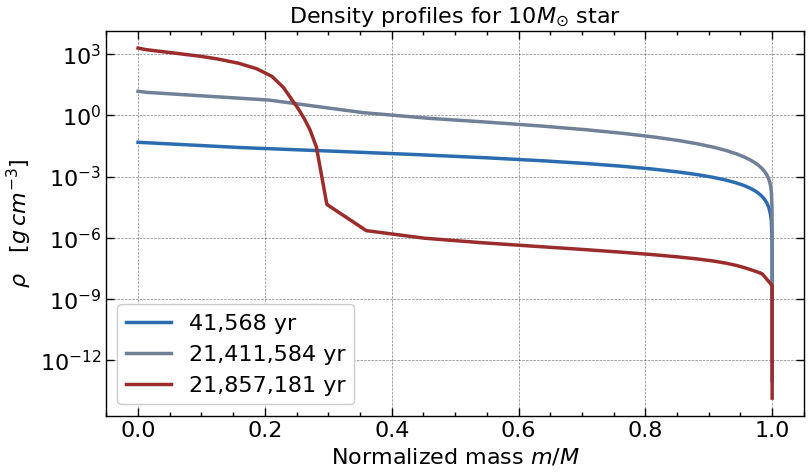

In [14]:
cols = ["#2B6CB0", "#718096", "#9B2C2C"]

fig,ax = plt.subplots(figsize=(9,5))

for i,n in enumerate([100,1000,1500]):
    age = int(F8_str_info[n]["Age"])
    
    ax.plot(F8_str[n]["M"], F8_str[n]["RHO"], c=cols[i], lw=2.5, label=f"{age:,} yr")

ax.set_xlabel("Normalized mass $m/M$")
ax.set_ylabel(r"$\rho\quad [g\,cm^{-3}]$")
ax.set_yscale("log")
ax.set_title("Density profiles for $10 M_{\odot}$ star")
ax.legend()
plt.show()

## 6. Linking F7 phases to F8 profiles
The F7 track and the F8 file share a common **model number** (`ModNumb` / `MODE`). This is the key to extracting the radial profile corresponding to a specific evolutionary phase:

1. Use `phase_selector` on the F7 track to get the `MODE` (model number) at a given phase.
2. Find the matching index in `F8_str_info["ModNumb"]`.
3. Access the profile with `F8_str[index]`.

In [15]:
# get the MODE of the one with M=10 when in ZAMS and in TAMS
izams_mode = M10.phase_selector("ZAMS")["MODE"]
itams_mode = M10.phase_selector("TAMS")["MODE"]
print(f"F7 MODE\n\nZAMS: {izams_mode}\nTAMS: {itams_mode}")

# global properties of stars from F7 when in ZAMS
pd.DataFrame(set_sub.phase_selector("ZAMS")).head()

F7 MODE

ZAMS: 572.0
TAMS: 1440.0


,MODE,MASS,AGE,Dtime,LOG_L,LOG_TE,RSTAR,CONV,QSCHW,QDISC,...,R20L10,MU20,T2_3L10,RH2_3L10,P2_3L10,TE2_3L10,R2_3L10,MU2_3,FIT_M,COMP_TIME
0,506.0,1.999956,4.585620e+07,2.667954e+06,1.203278,3.958648,1.123144e+11,0.198048,0.129217,0.380422,...,11.050065,0.691520,3.962831,-8.122181,3.696665,3.958647,11.050437,0.715169,0.999,536.784
1,547.0,2.999938,1.582189e+07,9.206759e+05,1.898153,4.086660,1.386278e+11,0.265545,0.190941,0.335456,...,11.140795,0.664904,4.089218,-9.075261,3.108049,4.086660,11.141849,0.698973,0.999,591.268
2,553.0,3.999920,7.771978e+06,4.580539e+05,2.372697,4.170436,1.627680e+11,0.305246,0.221855,0.320518,...,11.210456,0.660937,4.170560,-8.984963,3.297342,4.170436,11.211570,0.682033,0.999,568.752
3,546.0,4.999901,4.585761e+06,2.637550e+05,2.729015,4.232055,1.847103e+11,0.322511,0.241870,0.328146,...,11.265349,0.655844,4.235082,-8.911394,3.455270,4.232056,11.266488,0.658068,0.999,650.464
4,556.0,5.999886,2.911143e+06,1.766618e+05,3.011997,4.280547,2.046431e+11,0.344422,0.256365,0.351288,...,11.309846,0.651666,4.283608,-8.866514,3.561674,4.280549,11.310993,0.655955,0.999,709.843


In [16]:
# find corresponding indices in F8
izams_f8 = (F8_str_info["ModNumb"] == izams_mode).argmax()
itams_f8 = (F8_str_info["ModNumb"] == itams_mode).argmax()
print(f"F8 ModNumb\n\nZAMS: {izams_f8}\nTAMS: {itams_f8}")

pd.DataFrame(F8_str_info).head()

F8 ModNumb

ZAMS: 342
TAMS: 1210


,ModNumb,my_k,AK_ENV_MD,AK_ROS_MD,A_IH_BNV_MD,A_IHE_BNV_MD,A_IC_BNV_MD,GMS_0,Age
0,230.0,38.0,36.0,0.0,38.0,0.0,0.0,10.0,0.100000
1,231.0,38.0,36.0,0.0,38.0,0.0,0.0,10.0,124.480214
2,232.0,38.0,36.0,0.0,38.0,0.0,0.0,10.0,264.407955
3,233.0,38.0,36.0,0.0,38.0,0.0,0.0,10.0,421.826663
4,234.0,38.0,36.0,0.0,38.0,0.0,0.0,10.0,598.922710


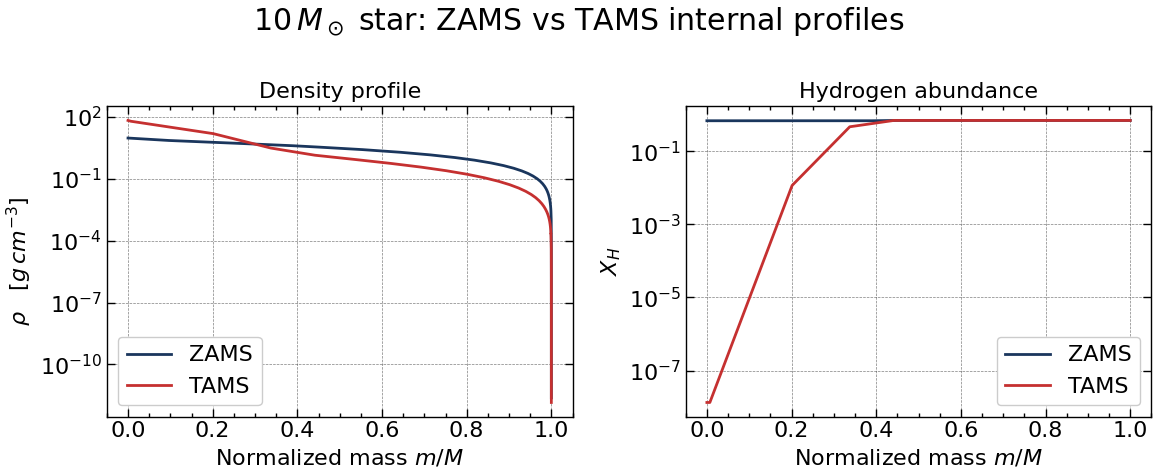

In [17]:
cols = ["#1A365D", "#C53030"]

prof_zams = pd.DataFrame(F8_str[izams_f8])
prof_tams = pd.DataFrame(F8_str[itams_f8])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# density
axes[0].plot(prof_zams["M"], prof_zams["RHO"], c=cols[0], label="ZAMS")
axes[0].plot(prof_tams["M"], prof_tams["RHO"], c=cols[1], label="TAMS")
axes[0].set_yscale("log")
axes[0].set_xlabel("Normalized mass $m/M$")
axes[0].set_ylabel(r"$\rho\quad [g\,cm^{-3}]$")
axes[0].set_title("Density profile")
axes[0].legend()

# hydrogen mass fraction
axes[1].plot(prof_zams["M"], prof_zams["XH"], c=cols[0], label="ZAMS")
axes[1].plot(prof_tams["M"], prof_tams["XH"], c=cols[1], label="TAMS")
axes[1].set_yscale("log")
axes[1].set_xlabel("Normalized mass $m/M$")
axes[1].set_ylabel("$X_H$")
axes[1].set_title("Hydrogen abundance")
axes[1].legend()

fig.suptitle(r"$10\,M_\odot$ star: ZAMS vs TAMS internal profiles")
fig.tight_layout()
plt.show()

## Quick reference
| Task | Code |
| --- | --- |
| Load a set | `Load_Set(path, fread=True, fsave=True)` |
| Load all sets in a directory | `Find_and_load_Sets(path)` |
| List tracks | `set.info` |
| Access evolutionary sequence | `track.seq` (post-ZAMS), `track.preseq` (pre-MS) |
| Select by mass | `set.SelEq("mass", value_or_list)` |
| Get phase row | `set.phase_selector("ZAMS")` |
| Quick HR plot | `set.HR_plot(ax)` |
| Load F8 profiles | `read_F8(file)` → `F8_str, F8_str_info, F8_track_info` |
| Link F7 phase → F8 profile | match `MODE` to `ModNumb`, use `argmax()` |